In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import seaborn as sns  # a useful plotting library on top of matplotlib
from tqdm.auto import tqdm # a nice progress bar


/opt/anaconda3/envs/mainenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


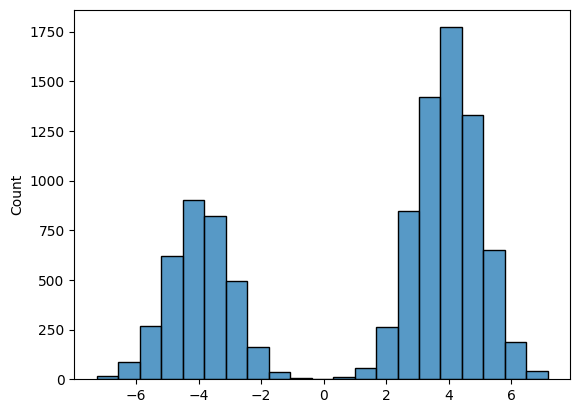

In [14]:
# generate a dataset of 1D data from a mixture of two Gaussians
# this is a simple example, but you can use any distribution
data_distribution = torch.distributions.mixture_same_family.MixtureSameFamily(
    torch.distributions.Categorical(torch.tensor([1, 2])),
    torch.distributions.Normal(torch.tensor([-4., 4.]), torch.tensor([1., 1.]))
)

dataset = data_distribution.sample(torch.Size([10000]))  # create training data set
dataset_validation = data_distribution.sample(torch.Size([1000])) # create validation data set
fig, ax = plt.subplots(1, 1)
sns.histplot(dataset)
plt.show()

In [15]:
# we will keep these parameters fixed throughout
# these parameters should give you an acceptable result
# but feel free to play with them
TIME_STEPS = 250
BETA = torch.tensor(0.02)
N_EPOCHS = 1000
BATCH_SIZE = 64
LEARNING_RATE = 0.8e-4

In [16]:
# define the neural network that predicts the amount of noise that was
# added to the data
# the network should have two inputs (the current data and the time step)
# and one output (the predicted noise)

g = torch.nn.Sequential(
    torch.nn.Linear(2, 64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, 64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, 1)
)
optimizer = torch.optim.Adam(g.parameters(), lr=LEARNING_RATE)
loss_fn = torch.nn.MSELoss()

In [17]:
epochs = tqdm(range(N_EPOCHS))  # this makes a nice progress bar

# Lists to store the loss history for plotting
train_losses = []
val_losses = []

for e in epochs: # loop over epochs
    g.train()

    epoch_train_loss = 0.0
    num_batches = 0
    # loop through batches of the dataset, reshuffling it each epoch
    indices = torch.randperm(dataset.shape[0])
    shuffled_dataset = dataset[indices]
    for i in range(0, shuffled_dataset.shape[0] - BATCH_SIZE, BATCH_SIZE):
        # sample a batch of data
        x0 = shuffled_dataset[i:i + BATCH_SIZE]

        # here, implement algorithm 1 of the DDPM paper (https://arxiv.org/abs/2006.11239)
        t = torch.randint(1, TIME_STEPS + 1, (x0.shape[0],))
        epsilon = torch.randn_like(x0)
        alpha_bar = (1 - BETA) ** t
        xt = torch.sqrt(alpha_bar) * x0 + torch.sqrt(1 - alpha_bar) * epsilon
        
        # Concat x_t and normalized time into a single vector
        xt_t = torch.stack([xt, t.float() / TIME_STEPS], dim=1)
        epsilon_theta = g(xt_t).squeeze(-1)
        loss = loss_fn(epsilon_theta, epsilon)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Accumulate the training loss for this batch
        epoch_train_loss += loss.item()
        num_batches += 1
    # Record the average tr
    # aining loss for this epoch
    train_losses.append(epoch_train_loss / num_batches)


    # compute the loss on the validation set
    g.eval()
    with torch.no_grad():
        x0 = dataset_validation
        t = torch.randint(1, TIME_STEPS + 1, (x0.shape[0],))
        epsilon = torch.randn_like(x0)
        alpha_bar = (1 - BETA) ** t
        xt = torch.sqrt(alpha_bar) * x0 + torch.sqrt(1 - alpha_bar) * epsilon

        xt_t = torch.stack([xt, t.float() / TIME_STEPS], dim=1)
        epsilon_theta = g(xt_t).squeeze()
        val_loss = loss_fn(epsilon_theta, epsilon)
        #epochs.set_postfix({'val_loss': val_loss.item()})

         # Record the validation loss
        val_losses.append(val_loss.item())
        
        epochs.set_postfix({'train_loss': train_losses[-1], 'val_loss': val_loss.item()})

100%|██████████| 1000/1000 [01:06<00:00, 15.10it/s, train_loss=0.391, val_loss=0.418]


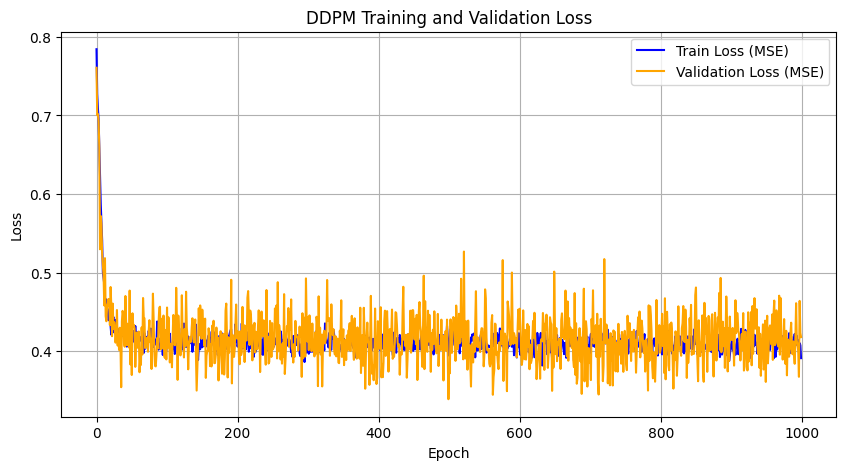

In [18]:
# Plot the losses after training finishes
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss (MSE)", color="blue")
plt.plot(val_losses, label="Validation Loss (MSE)", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DDPM Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def sample_reverse(g, count, return_trajectories=False):
    """
    Sample from the model by applying the reverse diffusion process

    Here, implement algorithm 2 of the DDPM paper (https://arxiv.org/abs/2006.11239)

    Parameters
    ----------
    g : torch.nn.Module
        The neural network that predicts the noise added to the data
    count : int
        The number of samples to generate in parallel

    (more)
    return_trajectories : bool
        If True, returns a tuple of (final_samples, trajectories)

    Returns
    -------
    x : torch.Tensor
        The final sample from the model
    (more)
    trajectories : np.ndarray (optional)
        Array of shape (TIME_STEPS+1, count) containing the full paths
    """
    g.eval()
    xt = torch.randn(count)

    # Store trajectories. First entry is at t=250
    trajectories = [xt.detach().numpy().copy()]
    
    with torch.no_grad():
        for t in reversed(range(1, TIME_STEPS + 1)):
            z = torch.randn(count) if t > 1 else torch.zeros(count)
            t_tensor = torch.full((count,), t)
            xt_t = torch.stack([xt, t_tensor.float() / TIME_STEPS], dim=1)
            epsilon_theta = g(xt_t).squeeze()
            
            alpha = 1 - BETA
            alpha_bar = (1 - BETA) ** t
            
            # Predict the denoised previous state
            xt = (1 / torch.sqrt(alpha)) * (xt - ((1 - alpha) / torch.sqrt(1 - alpha_bar)) * epsilon_theta) + torch.sqrt(BETA) * z

            trajectories.append(xt.detach().numpy().copy())

    if return_trajectories:
        return xt, np.array(trajectories)

    return xt

Text(0, 0.5, 'Sample count')

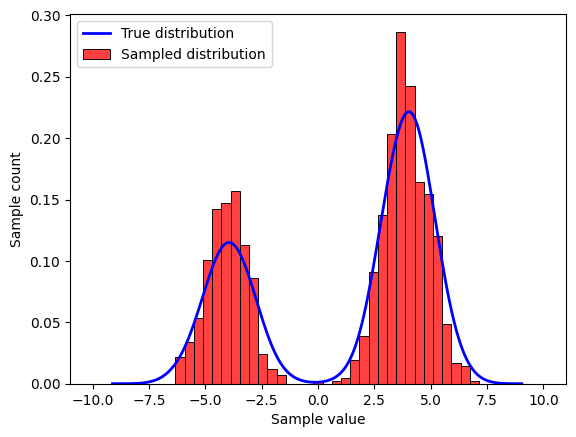

In [24]:
samples = sample_reverse(g, 1000)
samples = samples.detach().numpy()

# plot the samples
fig, ax = plt.subplots(1, 1)
bins = np.linspace(-10, 10, 50)
sns.kdeplot(dataset, ax=ax, color='blue', label='True distribution', linewidth=2)
sns.histplot(samples, ax=ax, bins=bins, color='red', label='Sampled distribution', stat='density')
ax.legend()
ax.set_xlabel('Sample value')
ax.set_ylabel('Sample count')

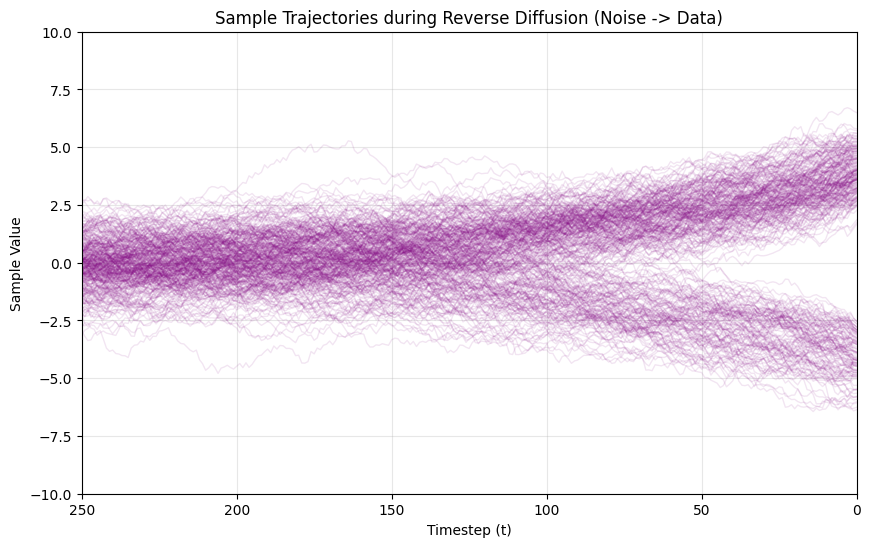

In [27]:
#plot the sample trajectories with different diffusion steps
samples, trajectories = sample_reverse(g, count=300, return_trajectories=True)

# Timesteps from TIME_STEPS down to 0
timesteps = np.arange(TIME_STEPS, -1, -1)
    
plt.figure(figsize=(10, 6))
    
# Plot all trajectories. Using a low alpha (transparency) helps show density
plt.plot(timesteps, trajectories, color='purple', alpha=0.1, linewidth=1)
        
# Reverse the X-axis so it reads from Noise (left) to Data (right)
plt.xlim(TIME_STEPS, 0)
plt.ylim(-10, 10)
plt.xlabel("Timestep (t)")
plt.ylabel("Sample Value")
plt.title("Sample Trajectories during Reverse Diffusion (Noise -> Data)")
plt.grid(True, alpha=0.3)
plt.show()

